In [1]:
 # ── COLAB SETUP ─────────────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
WORK_DIR = Path("/content/drive/MyDrive/mlvr1_eurlex")
print(f"✅ Working directory: {WORK_DIR}")

Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/mlvr1_eurlex


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torch.cuda.amp import autocast, GradScaler       # ← Mixed Precision (fp16)
import pickle
from transformers import AutoTokenizer, RobertaModel
from datasets import load_dataset
from sklearn.metrics import f1_score, ndcg_score
from sklearn.decomposition import IncrementalPCA      # ← Dimension Reduction
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

NUM_LABELS  = 100
EMBED_DIM   = 768   # RoBERTa hidden size
REDUCED_DIM = 512   # PCA target — 3x fewer params in classifier, 3x faster
                    # 256 dims retain ~95% variance in legal text embeddings
print(f'Embedding: {EMBED_DIM}D → PCA → {REDUCED_DIM}D  (speed-up: ~3×)')

Using device: cuda
Embedding: 768D → PCA → 512D  (speed-up: ~3×)


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# DATASET CONFIG — change ONLY these 3 things for a new dataset
# ══════════════════════════════════════════════════════════════════════════
# 1. NUM_LABELS  in Cell 1
# 2. Load your dataset below (replace load_dataset line)
# 3. adj_matrix  is built automatically from co-occurrence (no manual work)
# Everything else — PCA, models, loss, threshold tuning — zero change.
# ══════════════════════════════════════════════════════════════════════════

# ── Load Augmented Data ───────────────────────────────────────────────────────
with open(f'{WORK_DIR}/augmented_data.pkl', 'rb') as f:
    aug_data = pickle.load(f)
augmented_texts  = aug_data['texts']
augmented_labels = aug_data['labels']
print(f"✅ Augmented data: {len(augmented_texts)} examples")

# ── Build Adjacency Matrix from co-occurrence (GENERIC — works on any dataset) ─
def build_adj_matrix(label_lists, num_labels, threshold=0.01):
    """
    Builds a normalized label co-occurrence adjacency matrix.
    Works on ANY multi-label dataset — no dataset-specific assumptions.

    Args:
        label_lists : list of lists, each inner list = label indices for one sample
        num_labels  : total number of labels
        threshold   : min normalized co-occurrence to keep an edge (default 0.01)

    Returns:
        adj : torch.FloatTensor of shape (num_labels, num_labels)
    """
    import numpy as np
    co = np.zeros((num_labels, num_labels), dtype=np.float32)
    for labs in label_lists:
        for i in labs:
            for j in labs:
                if 0 <= i < num_labels and 0 <= j < num_labels:
                    co[i][j] += 1.0
    # Row-normalize: co[i][j] = P(j | i)
    row_sum = co.sum(axis=1, keepdims=True)
    row_sum = np.maximum(row_sum, 1.0)           # avoid div-by-zero
    adj = co / row_sum
    adj[adj < threshold] = 0.0                   # sparsify
    np.fill_diagonal(adj, 1.0)                   # self-loops
    return torch.tensor(adj, dtype=torch.float32)

# ── Load or build adj_matrix ──────────────────────────────────────────────────
ADJ_CACHE = WORK_DIR / 'adj_matrix_auto.pt'
if os.path.exists(ADJ_CACHE):
    adj_matrix = torch.load(ADJ_CACHE, map_location='cpu')
    print(f"✅ Adjacency matrix loaded from cache: {adj_matrix.shape}")
else:
    # Try loading pre-built matrix first
    legacy_path = WORK_DIR / 'adj_matrix.pt'
    if os.path.exists(legacy_path):
        adj_matrix = torch.load(legacy_path, map_location='cpu')
        print(f"✅ Adjacency matrix loaded (legacy): {adj_matrix.shape}")
    else:
        # Build from scratch using training label co-occurrence
        print("🔄 Building adjacency matrix from label co-occurrence...")
        # NOTE: for a new dataset, pass your train label lists here
        # e.g. build_adj_matrix(your_train_label_lists, NUM_LABELS)
        # For EURLex we temporarily load to get label lists:
        _ds = load_dataset('lex_glue', 'eurlex', split='train')
        _label_lists = [ex['labels'] for ex in _ds]
        adj_matrix = build_adj_matrix(_label_lists, NUM_LABELS)
        torch.save(adj_matrix, ADJ_CACHE)
        print(f"✅ Adjacency matrix built & saved: {adj_matrix.shape}")

# ── Load label2id (optional — only needed if using label names) ───────────────
label2id_path = WORK_DIR / 'label2id.pkl'
if os.path.exists(label2id_path):
    with open(label2id_path, 'rb') as f:
        label2id = pickle.load(f)
    print("✅ label2id loaded")
else:
    label2id = None
    print("ℹ️  label2id not found — skipping (not required for training)")

✅ Augmented data: 7866 examples
✅ Adjacency matrix loaded (legacy): torch.Size([100, 100])
✅ label2id loaded


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# DIMENSION REDUCTION PIPELINE
# ══════════════════════════════════════════════════════════════════════════
# STRATEGY: Instead of running RoBERTa forward pass EVERY training iteration
# (which is ~95% of the compute), we:
#   1. Run RoBERTa ONCE on the entire dataset  → extract CLS embeddings (768D)
#   2. Fit PCA (768D → 256D) on training embeddings
#   3. All downstream models work on 256D vectors (3× smaller, 3× faster)
#
# RESULT: Training time drops from ~2 days → ~2-4 hours on GPU
#         because the expensive Transformer forward pass runs only ONCE total,
#         not once per batch per epoch.
#
# QUALITY SAFEGUARD: PCA on 55k+ legal text embeddings retains ~95% variance.
#         We also add attention-pooling (weighted avg of all token positions)
#         instead of only the CLS token — better contextual representation.
# ══════════════════════════════════════════════════════════════════════════

tokenizer = AutoTokenizer.from_pretrained('roberta-base')
print("✅ Tokenizer loaded")

# ── Step A: Tokenize everything ──────────────────────────────────────────────
print("\n🔄 Step A: Loading and tokenizing Eurlex dataset...")
datasets_raw = load_dataset('lex_glue', 'eurlex')

def preprocess(example):
    binary = [0] * NUM_LABELS
    for lab in example['labels']:
        if 0 <= lab < NUM_LABELS:
            binary[lab] = 1
    return {'text': example['text'], 'labels': binary}

dataset = datasets_raw.map(preprocess)
tokenized_datasets = dataset.map(
    lambda x: tokenizer(x['text'], padding='max_length', truncation=True, max_length=512),
    batched=True, remove_columns=['text']
)
tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
print(f"✅ Tokenized: train={len(tokenized_datasets['train'])} | val={len(tokenized_datasets['validation'])} | test={len(tokenized_datasets['test'])}")

# ── Step B: Extract RoBERTa embeddings (ONCE, not per epoch) ─────────────────
print("\n🔄 Step B: Extracting RoBERTa embeddings (runs once, saves to Drive)...")

EMBED_CACHE = {
    'train': WORK_DIR / 'embeddings_train.pt',
    'validation': WORK_DIR / 'embeddings_val.pt',
    'test': WORK_DIR / 'embeddings_test.pt',
    'aug':  WORK_DIR / 'embeddings_aug.pt',
}

def extract_embeddings(hf_split, batch_size=64):
    """
    Extract mean-pooled embeddings from RoBERTa for an HF dataset split.
    Mean pooling over all non-padding tokens (better than CLS-only).
    """
    roberta = RobertaModel.from_pretrained('roberta-base').to(device)
    roberta.eval()

    loader = DataLoader(hf_split, batch_size=batch_size, shuffle=False, num_workers=2)
    all_embeds = []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)

            with autocast():                        # fp16 for extraction speed
                out = roberta(ids, mask)

            # MEAN POOLING: average all non-padding token embeddings
            # Better than CLS-only — captures full document context
            token_emb = out.last_hidden_state       # (B, 512, 768)
            mask_exp  = mask.unsqueeze(-1).float()  # (B, 512, 1)
            mean_emb  = (token_emb * mask_exp).sum(1) / mask_exp.sum(1)  # (B, 768)

            all_embeds.append(mean_emb.cpu().float())
            if i % 50 == 0:
                print(f"  batch {i}/{len(loader)}", end="\n")

    del roberta
    torch.cuda.empty_cache()
    return torch.cat(all_embeds, dim=0)   # (N, 768)

def extract_aug_embeddings(aug_texts, batch_size=64):
    """Extract embeddings for augmented (text) examples."""
    roberta = RobertaModel.from_pretrained('roberta-base').to(device)
    roberta.eval()
    all_embeds = []

    for start in range(0, len(aug_texts), batch_size):
        batch_texts = aug_texts[start:start+batch_size]
        enc = tokenizer(batch_texts, padding='max_length', truncation=True,
                        max_length=512, return_tensors='pt')
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)

        with torch.no_grad(), autocast():
            out = roberta(ids, mask)

        mask_exp = mask.unsqueeze(-1).float()
        mean_emb = (out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1)
        all_embeds.append(mean_emb.cpu().float())

        if (start // batch_size) % 20 == 0:
            print(f"  Aug batch {start//batch_size}/{len(aug_texts)//batch_size}", end="\n")

    del roberta
    torch.cuda.empty_cache()
    return torch.cat(all_embeds, dim=0)

# Run extraction (skip if already cached on Drive)
for split_name, cache_path in EMBED_CACHE.items():
    if not os.path.exists(cache_path):
        print(f"  Extracting {split_name}...")
        if split_name == 'aug':
            emb = extract_aug_embeddings(augmented_texts)
        else:
            emb = extract_embeddings(tokenized_datasets[split_name])
        torch.save(emb, cache_path)
        print(f"  ✅ Saved {split_name} embeddings: {emb.shape} → {cache_path}")
    else:
        print(f"  ✅ {split_name} embeddings already cached — skipping extraction")

# ── Step C: Load all embeddings ───────────────────────────────────────────────
print("\n🔄 Step C: Loading cached embeddings...")
train_emb = torch.load(EMBED_CACHE['train'])          # (N_train, 768)
val_emb   = torch.load(EMBED_CACHE['validation'])     # (N_val, 768)
test_emb  = torch.load(EMBED_CACHE['test'])           # (N_test, 768)
aug_emb   = torch.load(EMBED_CACHE['aug'])            # (N_aug, 768)
print(f"train: {train_emb.shape} | val: {val_emb.shape} | test: {test_emb.shape} | aug: {aug_emb.shape}")

# ── Step D: Fit IncrementalPCA (768D → 256D) on train embeddings ───────────────
PCA_CACHE = WORK_DIR / 'pca_model.pkl'

if not os.path.exists(PCA_CACHE):
    print(f"\n🔄 Step D: Fitting PCA {EMBED_DIM}D → {REDUCED_DIM}D on training set...")
    pca = IncrementalPCA(n_components=REDUCED_DIM, batch_size=2048)
    for start in range(0, len(train_emb), 2048):
        pca.partial_fit(train_emb[start:start+2048].numpy())
    with open(PCA_CACHE, 'wb') as f:
        pickle.dump(pca, f)
    var_explained = sum(pca.explained_variance_ratio_)
    print(f"  ✅ PCA fitted. Variance retained: {var_explained:.3f} ({var_explained*100:.1f}%)")
else:
    with open(PCA_CACHE, 'rb') as f:
        pca = pickle.load(f)
    print(f"\n✅ PCA loaded from cache. Variance retained: {sum(pca.explained_variance_ratio_):.3f}")

# ── Step E: Apply PCA transform ───────────────────────────────────────────────
print("\n🔄 Step E: Applying PCA transform...")
def pca_transform(emb_tensor):
    arr = emb_tensor.numpy()
    out = []
    for start in range(0, len(arr), 2048):
        out.append(pca.transform(arr[start:start+2048]))
    return torch.tensor(np.vstack(out), dtype=torch.float32)

train_emb_r = pca_transform(train_emb)   # (N_train, 256)
val_emb_r   = pca_transform(val_emb)     # (N_val, 256)
test_emb_r  = pca_transform(test_emb)    # (N_test, 256)
aug_emb_r   = pca_transform(aug_emb)     # (N_aug, 256)

# Save reduced embeddings
torch.save(train_emb_r, WORK_DIR / 'emb_r_train.pt')
torch.save(val_emb_r,   WORK_DIR / 'emb_r_val.pt')
torch.save(test_emb_r,  WORK_DIR / 'emb_r_test.pt')
torch.save(aug_emb_r,   WORK_DIR / 'emb_r_aug.pt')
print(f"✅ Reduced: train {train_emb_r.shape} | val {val_emb_r.shape} | test {test_emb_r.shape}")

# ── Step F: Build label tensors + DataLoaders ────────────────────────────────
print("\n🔄 Step F: Building DataLoaders from reduced embeddings...")
train_labels = torch.tensor(np.array(tokenized_datasets['train']['labels']), dtype=torch.float32)
val_labels   = torch.tensor(np.array(tokenized_datasets['validation']['labels']), dtype=torch.float32)
test_labels  = torch.tensor(np.array(tokenized_datasets['test']['labels']), dtype=torch.float32)
aug_labels   = torch.tensor(np.array(augmented_labels), dtype=torch.float32)

class EmbedDataset(Dataset):
    def __init__(self, embeds, labels):
        self.embeds = embeds
        self.labels = labels
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {'embed': self.embeds[i], 'labels': self.labels[i]}

orig_train_ds  = EmbedDataset(train_emb_r, train_labels)
val_ds         = EmbedDataset(val_emb_r,   val_labels)
test_ds        = EmbedDataset(test_emb_r,  test_labels)
aug_ds         = EmbedDataset(aug_emb_r,   aug_labels)
combined_ds    = ConcatDataset([orig_train_ds, aug_ds])

orig_train_loader = DataLoader(orig_train_ds, batch_size=256, shuffle=True,  num_workers=4, pin_memory=True)
val_loader        = DataLoader(val_ds,        batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
test_loader       = DataLoader(test_ds,       batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
combined_loader   = DataLoader(combined_ds,   batch_size=256, shuffle=True,  num_workers=4, pin_memory=True)

# NOTE on batch_size: with pre-extracted 256D vectors (no transformer forward),
# batch_size=256 fits easily in GPU memory and runs ~100× faster per batch
# vs batch_size=8 with live RoBERTa.

print(f"✅ DataLoaders ready")
print(f"   orig_train: {len(orig_train_loader)} batches @ bs=256")
print(f"   combined  : {len(combined_loader)} batches @ bs=256")
print(f"   val       : {len(val_loader)} batches @ bs=256")
print(f"\n⚡ Speed estimate: ~2 hrs total (vs ~48 hrs before)")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/55000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ Tokenized: train=55000 | val=5000 | test=5000

🔄 Step B: Extracting RoBERTa embeddings (runs once, saves to Drive)...
  ✅ train embeddings already cached — skipping extraction
  ✅ validation embeddings already cached — skipping extraction
  ✅ test embeddings already cached — skipping extraction
  ✅ aug embeddings already cached — skipping extraction

🔄 Step C: Loading cached embeddings...
train: torch.Size([55000, 768]) | val: torch.Size([5000, 768]) | test: torch.Size([5000, 768]) | aug: torch.Size([7866, 768])

✅ PCA loaded from cache. Variance retained: 0.996

🔄 Step E: Applying PCA transform...
✅ Reduced: train torch.Size([55000, 512]) | val torch.Size([5000, 512]) | test torch.Size([5000, 512])

🔄 Step F: Building DataLoaders from reduced embeddings...
✅ DataLoaders ready
   orig_train: 215 batches @ bs=256
   combined  : 246 batches @ bs=256
   val       : 20 batches @ bs=256

⚡ Speed estimate: ~2 hrs total (vs ~48 hrs before)


In [5]:
# ── FIXED COMPONENTS ─────────────────────────────────────────────────────────
# CHANGES from original:
#   1. DistributionBalancedLoss: beta 0.9999→0.999 (44x→~8x weight spread)
#   2. LabelCorrelationModule: FIXED residual (sigmoid first + learnable alpha)
#      old code: torch.matmul(logits, adj) — corrupted raw logit magnitudes
#   3. AdaptiveThreshold: unchanged

class DistributionBalancedLoss(nn.Module):
    def __init__(self, num_labels, beta=0.999):   # FIX: was 0.9999
        super().__init__()
        self.beta = beta
        self.num_labels = num_labels
        self.register_buffer('weights', torch.ones(num_labels))

    def compute_weights(self, train_labels):
        n_c = train_labels.sum(dim=0).float() + 1e-8
        self.weights = (1 - self.beta) / (1 - torch.pow(self.beta, n_c))
        self.weights = self.weights / self.weights.sum() * self.num_labels
        print(f'✅ DB Weights — Min: {self.weights.min():.4f}  Max: {self.weights.max():.4f}')

    def forward(self, logits, targets):
        return nn.BCEWithLogitsLoss(
            weight=self.weights.to(logits.device), reduction='mean'
        )(logits, targets.float())


class LabelCorrelationModule(nn.Module):
    # FIX: old code did matmul(logits, adj) — wrong, distorted raw logit values
    # New: sigmoid first (probability space), then learnable residual weight alpha
    def __init__(self, num_labels, adj_matrix):
        super().__init__()
        self.register_buffer('adj', adj_matrix)
        self.alpha = nn.Parameter(torch.tensor(0.1))   # learnable, starts small

    def forward(self, logits):
        corr = torch.matmul(torch.sigmoid(logits), self.adj)   # prob space
        return logits + self.alpha * corr                       # residual

class AdaptiveThreshold(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.tau = nn.Parameter(torch.zeros(num_labels))

    def forward(self, logits):
        return logits - self.tau.unsqueeze(0)

print("✅ Components defined (DB beta=0.999, Correlation residual-fixed)")

✅ Components defined (DB beta=0.999, Correlation residual-fixed)


In [6]:
# ── LIGHTWEIGHT MODELS (work on REDUCED_DIM=256 embeddings) ─────────────────
# All models now receive pre-computed 256D vectors — NO RoBERTa inside.
# Architecture: 256→512 (expand) → LayerNorm + Dropout → 512→num_labels
# The expansion layer (256→512) compensates for compression and gives the
# network enough capacity to learn non-linear label relationships.

class BaselineModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_labels)
        )
    def forward(self, embed):
        return self.net(embed)


class DBModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_labels)
        )
    def forward(self, embed):
        return self.net(embed)


class CorrelationModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_labels)
        )
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
    def forward(self, embed):
        logits = self.net(embed)
        return self.correlation(logits)


class AdaptiveModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_labels)
        )
        self.correlation     = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive_thresh = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        logits  = self.net(embed)
        refined = self.correlation(logits)
        return self.adaptive_thresh(refined)


class FullC2DBT(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_labels)
        )
        self.correlation     = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive_thresh = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        logits  = self.net(embed)
        refined = self.correlation(logits)
        return self.adaptive_thresh(refined)


print("✅ Lightweight models defined (input: 256D PCA embeddings)")
total_params = sum(p.numel() for p in FullC2DBT(NUM_LABELS, adj_matrix).parameters())
print(f"   FullC2DBT params: {total_params:,}  (vs ~125M for RoBERTa-based — 99% smaller)")

✅ Lightweight models defined (input: 256D PCA embeddings)
   FullC2DBT params: 315,081  (vs ~125M for RoBERTa-based — 99% smaller)


In [7]:
# ── CHECKPOINT LOADER HELPER ─────────────────────────────────────────────────
def load_checkpoint(model, model_name, suffix='best'):
    path = f"{WORK_DIR}/{model_name}_{suffix}.pth"
    if os.path.exists(path):
        state = torch.load(path, map_location=device)
        model.load_state_dict(state)
        print(f"✅ Loaded {path}")
        return model
    path2 = f"{WORK_DIR}/{model_name}_epoch5.pth"
    if os.path.exists(path2):
        state = torch.load(path2, map_location=device)
        model.load_state_dict(state)
        print(f"✅ Loaded {path2}")
        return model
    print(f"⚠️  Not found: {path} or {path2}")
    return None

In [8]:
# ── METRICS HELPERS (unchanged) ──────────────────────────────────────────────
def precision_at_k(y_true, y_scores, k):
    n = y_true.shape[0]
    res = []
    for i in range(n):
        top = np.argsort(y_scores[i])[::-1][:k]
        res.append(y_true[i][top].sum() / k)
    return float(np.mean(res))

def ndcg_at_k(y_true, y_scores, k):
    return float(np.mean([ndcg_score([y_true[i]], [y_scores[i]], k=k)
                           for i in range(len(y_true))]))

def compute_all_metrics(all_labels, all_probs):
    preds  = (all_probs > 0.5).astype(float)
    micro  = f1_score(all_labels, preds, average='micro',  zero_division=0)
    macro  = f1_score(all_labels, preds, average='macro',  zero_division=0)
    return {
        'Micro-F1': micro,   'Macro-F1': macro,
        'P@1': precision_at_k(all_labels, all_probs, 1),
        'P@3': precision_at_k(all_labels, all_probs, 3),
        'P@5': precision_at_k(all_labels, all_probs, 5),
        'NDCG@1': ndcg_at_k(all_labels, all_probs, 1),
        'NDCG@3': ndcg_at_k(all_labels, all_probs, 3),
        'NDCG@5': ndcg_at_k(all_labels, all_probs, 5),
    }

print("✅ Metrics defined")

✅ Metrics defined


In [9]:
# ── FAST train_model — GradScaler + CosineAnnealingLR + best-ckpt ───────────
# CHANGES from original:
#   1. Batch format: 'embed' key (not input_ids/attention_mask) — no transformer
#   2. GradScaler for mixed-precision stability
#   3. CosineAnnealingLR — smooth LR decay
#   4. best-checkpoint saved separately (best val Micro-F1, not just last epoch)
#   5. Label smoothing (eps=0.05) on BCE — reduces overconfidence

def train_model(model, train_loader, val_loader, optimizer, criterion=None,
                epochs=15, model_name='model', label_smooth=0.05):
    """
    label_smooth: replaces hard {0,1} targets with {eps/2, 1-eps/2}.
    Prevents the model from being overconfident on sparse multi-label targets.
    """
    history = {k: [] for k in ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']}
    scaler    = GradScaler()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    best_mf1  = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            embed  = batch['embed'].to(device)
            labels = batch['labels'].to(device).float()

            # Label smoothing: {0→0.025, 1→0.975}
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2

            optimizer.zero_grad()
            with autocast():                        # fp16 forward pass
                logits = model(embed)
                loss   = (criterion(logits, labels) if criterion
                          else nn.BCEWithLogitsLoss()(logits, labels))

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # grad clip
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}  LR: {lr_now:.2e}')

        # ── Validate ──
        model.eval()
        all_probs, all_labels_list = [], []
        with torch.no_grad():
            for batch in val_loader:
                embed  = batch['embed'].to(device)
                labels = batch['labels'].to(device)
                with autocast():
                    logits = model(embed)
                probs = torch.sigmoid(logits)
                all_probs.append(probs.cpu().float().numpy())
                all_labels_list.append(labels.cpu().numpy())

        all_probs  = np.vstack(all_probs)
        all_lbls   = np.vstack(all_labels_list)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items():
            history[k].append(v)

        print(f'  Val Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
              f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | P@5: {m["P@5"]:.4f} '
              f'| NDCG@1: {m["NDCG@1"]:.4f} | NDCG@3: {m["NDCG@3"]:.4f} | NDCG@5: {m["NDCG@5"]:.4f}')

        torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_epoch{epoch+1}.pth')
        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']
            torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_best.pth')
            print(f'  💾 Best checkpoint  Micro-F1={best_mf1:.4f}')

    print(f'\n✅ Done. Best Val Micro-F1: {best_mf1:.4f}')
    return history

In [10]:
# ── ABLATION STUDY ───────────────────────────────────────────────────────────
# Step 1 & 2 (Baseline, DB Loss): evaluate from saved Drive checkpoints
#   → These ran on the OLD RoBERTa pipeline; their results are valid baselines.
#     We reload their epoch-5 weights into the NEW lightweight head architecture.
#     NOTE: if their checkpoints were saved from old RoBERTa-inside models,
#     you need to re-train them too (same code, just run train_model for them).
#     Set RETRAIN_BASELINE = True below if that is the case.
# Step 3-5: train fresh with all fixes applied.
# ──────────────────────────────────────────────────────────────────────────────

RETRAIN_BASELINE = True   # ← Set False only if old checkpoints match new arch

adj = adj_matrix.to(device)

db_criterion = DistributionBalancedLoss(NUM_LABELS)
db_criterion.compute_weights(train_labels)   # train_labels defined in Cell 3
db_criterion = db_criterion.to(device)

def evaluate_model(model, val_loader, label):
    """Evaluate a pre-loaded model on val_loader. Returns single-point history."""
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in val_loader:
            embed  = batch['embed'].to(device)
            labels = batch['labels']
            with autocast():
                logits = model(embed)
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(labels.numpy())
    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)
    m = compute_all_metrics(all_lbls, all_probs)
    print(f'{label:22} → Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
          f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | NDCG@3: {m["NDCG@3"]:.4f}')
    return {k: [v] for k, v in m.items()}

# ══ STEP 1: Baseline ══════════════════════════════════════════════════════════
print("\n🔄 Step 1: Baseline")
baseline_model = BaselineModel(NUM_LABELS).to(device)
if RETRAIN_BASELINE:
    opt = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3, weight_decay=1e-4)
    baseline_hist = train_model(baseline_model, orig_train_loader, val_loader,
                                opt, epochs=15, model_name='baseline_pca')
else:
    baseline_model = load_checkpoint(baseline_model, 'baseline')
    baseline_hist  = evaluate_model(baseline_model, val_loader, "Baseline")

# ══ STEP 2: DB Loss ══════════════════════════════════════════════════════════
print("\n🔄 Step 2: DB Loss")
db_model = DBModel(NUM_LABELS).to(device)
if RETRAIN_BASELINE:
    opt = torch.optim.AdamW(db_model.parameters(), lr=1e-3, weight_decay=1e-4)
    db_hist = train_model(db_model, orig_train_loader, val_loader,
                          opt, criterion=db_criterion, epochs=15, model_name='db_pca')
else:
    db_model  = load_checkpoint(db_model, 'db')
    db_hist   = evaluate_model(db_model, val_loader, "DB Loss")

# ══ STEP 3: Correlation (FIXED residual) ══════════════════════════════════════
print("\n🔄 Step 3: Correlation (fixed residual)")
corr_model = CorrelationModel(NUM_LABELS, adj).to(device)
opt = torch.optim.AdamW(corr_model.parameters(), lr=1e-3, weight_decay=1e-4)
corr_hist  = train_model(corr_model, orig_train_loader, val_loader,
                         opt, criterion=db_criterion, epochs=15, model_name='corr_pca')

# ══ STEP 4: Adaptive Threshold ════════════════════════════════════════════════
print("\n🔄 Step 4: Adaptive Threshold")
adapt_model = AdaptiveModel(NUM_LABELS, adj).to(device)
opt = torch.optim.AdamW([
    {'params': adapt_model.net.parameters(), 'weight_decay': 1e-4},
    {'params': adapt_model.correlation.parameters(), 'weight_decay': 1e-4},
    {'params': adapt_model.adaptive_thresh.parameters(), 'weight_decay': 1e-2}  # tau pe zyada penalty
], lr=1e-3)
adapt_hist  = train_model(adapt_model, orig_train_loader, val_loader,
                          opt, criterion=db_criterion, epochs=15, model_name='adapt_pca')

# ══ STEP 5: Full C²DB-T + LLM Aug ════════════════════════════════════════════
print("\n🔄 Step 5: Full C²DB-T + LLM Augmentation")
full_model = FullC2DBT(NUM_LABELS, adj).to(device)
opt = torch.optim.AdamW(full_model.parameters(), lr=1e-3, weight_decay=1e-4)
full_hist  = train_model(full_model, combined_loader, val_loader,
                         opt, criterion=db_criterion, epochs=15, model_name='full_pca')

print("\n✅ Steps 1-5 Complete!")

# ══ STEP 6: Correlation Model — Full RoBERTa Fine-tuning ══════════════════════
# WHY: PCA freezes RoBERTa representations. End-to-end fine-tuning lets the
#      encoder adapt to the task → closes the remaining ~0.03 Micro-F1 gap.
# DATASET-AGNOSTIC: just change NUM_LABELS + dataset in Cell 1/3 — same code.
# TIME: ~8-10 hrs on a single GPU (T4/V100). Run once, save checkpoint.
# ──────────────────────────────────────────────────────────────────────────────

print("\n🔄 Step 6: Correlation — Full RoBERTa fine-tuning (end-to-end)")

class CorrelationModelFull(nn.Module):
    """
    Full end-to-end model: RoBERTa encoder + LabelCorrelationModule.
    Receives raw token ids (not PCA embeddings).
    Architecture is identical to CorrelationModel but encoder is trainable.
    """
    def __init__(self, num_labels, adj_matrix, encoder_name='roberta-base'):
        super().__init__()
        # encoder_name can be swapped to 'xlm-roberta-base' for multilingual datasets
        self.roberta     = RobertaModel.from_pretrained(encoder_name)
        self.dropout     = nn.Dropout(0.1)
        self.classifier  = nn.Linear(768, num_labels)
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)

    def forward(self, input_ids, attention_mask):
        out      = self.roberta(input_ids, attention_mask)
        # Mean pooling — same as extraction step (consistent representations)
        mask_exp = attention_mask.unsqueeze(-1).float()
        pooled   = (out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1)
        logits   = self.classifier(self.dropout(pooled))
        return self.correlation(logits)


def train_model_full(model, train_loader, val_loader, optimizer,
                     criterion=None, epochs=10, model_name='model',
                     label_smooth=0.05, grad_accum=4):
    """
    Full fine-tuning variant of train_model.
    Uses gradient accumulation (grad_accum=4) so effective batch size = 32
    despite small per-step batch (bs=8) needed to fit RoBERTa in GPU memory.
    Everything else identical to train_model — same metrics, same checkpointing.
    """
    history  = {k: [] for k in ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']}
    scaler    = GradScaler()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_mf1  = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device).float()

            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2

            with autocast():
                logits = model(input_ids, attention_mask)
                loss   = (criterion(logits, labels) if criterion
                          else nn.BCEWithLogitsLoss()(logits, labels))
                loss   = loss / grad_accum          # normalize for accumulation

            scaler.scale(loss).backward()

            if (step + 1) % grad_accum == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item() * grad_accum

        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}  LR: {lr_now:.2e}')

        # ── Validate ──
        model.eval()
        all_probs, all_lbls_list = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                with autocast():
                    logits = model(input_ids, attention_mask)
                probs = torch.sigmoid(logits)
                all_probs.append(probs.cpu().float().numpy())
                all_lbls_list.append(labels.cpu().numpy())

        all_probs = np.vstack(all_probs)
        all_lbls  = np.vstack(all_lbls_list)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items():
            history[k].append(v)

        print(f'  Val Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
              f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | P@5: {m["P@5"]:.4f} '
              f'| NDCG@1: {m["NDCG@1"]:.4f} | NDCG@3: {m["NDCG@3"]:.4f} | NDCG@5: {m["NDCG@5"]:.4f}')

        torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_epoch{epoch+1}.pth')
        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']
            torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_best.pth')
            print(f'  💾 Best checkpoint  Micro-F1={best_mf1:.4f}')

    print(f'\n✅ Full fine-tuning done. Best Val Micro-F1: {best_mf1:.4f}')
    return history


# ── Token-level DataLoader (needed for RoBERTa — not PCA embeddings) ──────────
# tokenized_datasets is already built in Cell 3 — reuse it directly
ft_train_loader = DataLoader(tokenized_datasets['train'],      batch_size=8,
                             shuffle=True,  num_workers=2, pin_memory=True)
ft_val_loader   = DataLoader(tokenized_datasets['validation'], batch_size=8,
                             shuffle=False, num_workers=2, pin_memory=True)

# ── Build & train ─────────────────────────────────────────────────────────────
full_ft_model = CorrelationModelFull(NUM_LABELS, adj.cpu()).to(device)

# Layered LR: encoder gets 10× smaller LR than the classification head
# This is standard practice for fine-tuning pre-trained transformers
ft_optimizer = torch.optim.AdamW([
    {'params': full_ft_model.roberta.parameters(),     'lr': 2e-5, 'weight_decay': 0.01},
    {'params': full_ft_model.classifier.parameters(),  'lr': 2e-4, 'weight_decay': 1e-4},
    {'params': full_ft_model.correlation.parameters(), 'lr': 2e-4, 'weight_decay': 1e-4},
])

full_ft_hist = train_model_full(
    full_ft_model, ft_train_loader, ft_val_loader,
    optimizer   = ft_optimizer,
    criterion   = db_criterion,
    epochs      = 10,
    model_name  = 'corr_full_ft',
    label_smooth= 0.05,
    grad_accum  = 4    # effective batch = 8 × 4 = 32
)

print("\n✅ Ablation Study Complete (all 6 steps)!")


✅ DB Weights — Min: 0.4778  Max: 2.7734

🔄 Step 1: Baseline
Epoch 1/15 — Loss: 0.1977  LR: 9.89e-04
  Val Micro-F1: 0.6446 | Macro-F1: 0.3050 | P@1: 0.8832 | P@3: 0.7727 | P@5: 0.6383 | NDCG@1: 0.8834 | NDCG@3: 0.8097 | NDCG@5: 0.7854
  💾 Best checkpoint  Micro-F1=0.6446
Epoch 2/15 — Loss: 0.1663  LR: 9.57e-04
  Val Micro-F1: 0.6755 | Macro-F1: 0.3837 | P@1: 0.9024 | P@3: 0.7925 | P@5: 0.6621 | NDCG@1: 0.9023 | NDCG@3: 0.8307 | NDCG@5: 0.8117
  💾 Best checkpoint  Micro-F1=0.6755
Epoch 3/15 — Loss: 0.1620  LR: 9.05e-04
  Val Micro-F1: 0.6858 | Macro-F1: 0.4170 | P@1: 0.9112 | P@3: 0.7992 | P@5: 0.6610 | NDCG@1: 0.9113 | NDCG@3: 0.8381 | NDCG@5: 0.8143
  💾 Best checkpoint  Micro-F1=0.6858
Epoch 4/15 — Loss: 0.1594  LR: 8.36e-04
  Val Micro-F1: 0.6963 | Macro-F1: 0.4358 | P@1: 0.9122 | P@3: 0.8027 | P@5: 0.6706 | NDCG@1: 0.9123 | NDCG@3: 0.8411 | NDCG@5: 0.8217
  💾 Best checkpoint  Micro-F1=0.6963
Epoch 5/15 — Loss: 0.1574  LR: 7.52e-04
  Val Micro-F1: 0.6970 | Macro-F1: 0.4446 | P@1: 0.9

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 — Loss: 0.1597  LR: 1.95e-05
  Val Micro-F1: 0.7206 | Macro-F1: 0.5087 | P@1: 0.9368 | P@3: 0.8239 | P@5: 0.6793 | NDCG@1: 0.9369 | NDCG@3: 0.8648 | NDCG@5: 0.8378
  💾 Best checkpoint  Micro-F1=0.7206
Epoch 2/10 — Loss: 0.1433  LR: 1.82e-05
  Val Micro-F1: 0.7496 | Macro-F1: 0.5821 | P@1: 0.9410 | P@3: 0.8445 | P@5: 0.6880 | NDCG@1: 0.9418 | NDCG@3: 0.8826 | NDCG@5: 0.8496
  💾 Best checkpoint  Micro-F1=0.7496
Epoch 3/10 — Loss: 0.1396  LR: 1.61e-05
  Val Micro-F1: 0.7572 | Macro-F1: 0.5988 | P@1: 0.9418 | P@3: 0.8485 | P@5: 0.6943 | NDCG@1: 0.9418 | NDCG@3: 0.8851 | NDCG@5: 0.8542
  💾 Best checkpoint  Micro-F1=0.7572
Epoch 4/10 — Loss: 0.1372  LR: 1.34e-05
  Val Micro-F1: 0.7637 | Macro-F1: 0.6186 | P@1: 0.9374 | P@3: 0.8511 | P@5: 0.7125 | NDCG@1: 0.9375 | NDCG@3: 0.8866 | NDCG@5: 0.8683
  💾 Best checkpoint  Micro-F1=0.7637
Epoch 5/10 — Loss: 0.1352  LR: 1.05e-05
  Val Micro-F1: 0.7720 | Macro-F1: 0.6370 | P@1: 0.9408 | P@3: 0.8531 | P@5: 0.7055 | NDCG@1: 0.9406 | NDCG@3: 0

In [11]:
# ── PER-LABEL THRESHOLD TUNING — All 5 models ───────────────────────────────
# Applied to ALL models now (was only Full model before).
# Uses _best.pth checkpoint for each model.

def find_best_thresholds(model, val_loader, num_labels=100):
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in val_loader:
            embed  = batch['embed'].to(device)
            labels = batch['labels']
            with autocast():
                logits = model(embed)
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(labels.numpy())
    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)

    best_thresh = np.zeros(num_labels)
    print("🔧 Finding per-label thresholds...")
    for i in range(num_labels):
        max_f1, best_t = 0, 0.5
        for t in np.arange(0.1, 0.95, 0.02):
            pred = (all_probs[:, i] >= t).astype(int)
            f1   = f1_score(all_lbls[:, i], pred, zero_division=0)
            if f1 > max_f1:
                max_f1, best_t = f1, t
        best_thresh[i] = best_t

    preds_tuned = np.zeros_like(all_probs)
    for i in range(num_labels):
        preds_tuned[:, i] = (all_probs[:, i] >= best_thresh[i]).astype(float)
    m = compute_all_metrics(all_lbls, preds_tuned)
    print(f'  Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
          f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | P@5: {m["P@5"]:.4f}')
    return best_thresh, m

print("🔄 Threshold tuning — all 5 models...\n")

# NOTE: find_best_thresholds works on BOTH PCA models and Full fine-tuned model
# because it just needs model.eval() + forward pass — architecture-agnostic

def find_best_thresholds_ft(model, val_loader, num_labels=100):
    """Threshold tuning for full fine-tuned model (uses input_ids, not embed)."""
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels']
            with autocast():
                logits = model(input_ids, attention_mask)
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(labels.numpy())
    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)

    best_thresh = np.zeros(num_labels)
    print("🔧 Finding per-label thresholds...")
    for i in range(num_labels):
        max_f1, best_t = 0, 0.5
        for t in np.arange(0.1, 0.95, 0.02):
            pred = (all_probs[:, i] >= t).astype(int)
            f1   = f1_score(all_lbls[:, i], pred, zero_division=0)
            if f1 > max_f1:
                max_f1, best_t = f1, t
        best_thresh[i] = best_t

    preds_tuned = np.zeros_like(all_probs)
    for i in range(num_labels):
        preds_tuned[:, i] = (all_probs[:, i] >= best_thresh[i]).astype(float)
    m = compute_all_metrics(all_lbls, preds_tuned)
    print(f'  Micro-F1: {m["Micro-F1"]:.4f} | Macro-F1: {m["Macro-F1"]:.4f} '
          f'| P@1: {m["P@1"]:.4f} | P@3: {m["P@3"]:.4f} | P@5: {m["P@5"]:.4f}')
    return best_thresh, m

models_for_tuning = [
    (BaselineModel(NUM_LABELS),                   'baseline_pca', 'Baseline'),
    (DBModel(NUM_LABELS),                         'db_pca',       'DB Loss'),
    (CorrelationModel(NUM_LABELS, adj),           'corr_pca',     'Correlation'),
    (AdaptiveModel(NUM_LABELS, adj),              'adapt_pca',    'Adaptive'),
    (FullC2DBT(NUM_LABELS, adj),                  'full_pca',     'Full C²DB-T'),
]

all_thresholds = {}
tuned_results  = {}

for model_cls, ckpt_name, display_name in models_for_tuning:
    print(f"--- {display_name} ---")
    m = model_cls.to(device)
    best_path = f'{WORK_DIR}/{ckpt_name}_best.pth'
    m.load_state_dict(torch.load(best_path, map_location=device))
    thresh, metrics = find_best_thresholds(m, val_loader)
    all_thresholds[ckpt_name] = thresh
    tuned_results[display_name] = metrics
    print()

with open(f'{WORK_DIR}/best_thresholds_pca.pkl', 'wb') as f:
    pickle.dump(all_thresholds, f)
print("✅ PCA model thresholds saved.")

# ── Step 6: Full fine-tuned model threshold tuning ────────────────────────────
print("\n--- Full RoBERTa Fine-tuned (Step 6) ---")
_ft = CorrelationModelFull(NUM_LABELS, adj.cpu()).to(device)
_ft.load_state_dict(torch.load(f'{WORK_DIR}/corr_full_ft_best.pth', map_location=device))
ft_thresh, ft_metrics = find_best_thresholds_ft(_ft, ft_val_loader)
all_thresholds['corr_full_ft'] = ft_thresh
tuned_results['Corr Full FT'] = ft_metrics

with open(f'{WORK_DIR}/best_thresholds_all.pkl', 'wb') as f:
    pickle.dump(all_thresholds, f)
print("\n✅ All thresholds saved (PCA + Full FT).")

🔄 Threshold tuning — all 5 models...

--- Baseline ---
🔧 Finding per-label thresholds...
  Micro-F1: 0.7402 | Macro-F1: 0.6039 | P@1: 0.8108 | P@3: 0.7486 | P@5: 0.6438

--- DB Loss ---
🔧 Finding per-label thresholds...
  Micro-F1: 0.7362 | Macro-F1: 0.6099 | P@1: 0.8106 | P@3: 0.7426 | P@5: 0.6412

--- Correlation ---
🔧 Finding per-label thresholds...
  Micro-F1: 0.7353 | Macro-F1: 0.6079 | P@1: 0.8114 | P@3: 0.7431 | P@5: 0.6370

--- Adaptive ---
🔧 Finding per-label thresholds...
  Micro-F1: 0.7397 | Macro-F1: 0.6109 | P@1: 0.8134 | P@3: 0.7444 | P@5: 0.6448

--- Full C²DB-T ---
🔧 Finding per-label thresholds...
  Micro-F1: 0.7399 | Macro-F1: 0.6106 | P@1: 0.8284 | P@3: 0.7518 | P@5: 0.6401

✅ PCA model thresholds saved.

--- Full RoBERTa Fine-tuned (Step 6) ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔧 Finding per-label thresholds...
  Micro-F1: 0.7826 | Macro-F1: 0.6835 | P@1: 0.8666 | P@3: 0.8018 | P@5: 0.6754

✅ All thresholds saved (PCA + Full FT).


In [12]:
# ── FINAL RESULTS TABLE (all 6 steps) ────────────────────────────────────────
STEPS       = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C²DB-T+LLM', 'Corr Full FT']
all_hists   = [baseline_hist, db_hist, corr_hist, adapt_hist, full_hist, full_ft_hist]

def last(hist, key): return hist[key][-1]

METRIC_KEYS  = ['Micro-F1', 'Macro-F1', 'P@1', 'P@3', 'P@5', 'NDCG@1', 'NDCG@3', 'NDCG@5']
final_scores = {k: [last(h, k) for h in all_hists] for k in METRIC_KEYS}

header = f"{'Model':24}" + "".join(f"{k:>10}" for k in METRIC_KEYS)
print("\n" + "=" * len(header))
print("FINAL ABLATION RESULTS")
print("=" * len(header))
print(header)
print("-" * len(header))
for i, step in enumerate(STEPS):
    marker = " ← BEST" if i == 5 else ""
    row = f"{step:24}" + "".join(f"{final_scores[k][i]:>10.4f}" for k in METRIC_KEYS) + marker
    print(row)
print("=" * len(header))

# Also print tuned results
print("\n" + "=" * len(header))
print("AFTER THRESHOLD TUNING")
print("=" * len(header))
for name in STEPS:
    if name in tuned_results:
        m = tuned_results[name]
        row = f"{name:24}" + "".join(f"{m[k]:>10.4f}" for k in METRIC_KEYS)
        print(row)
print("=" * len(header))


FINAL ABLATION RESULTS
Model                     Micro-F1  Macro-F1       P@1       P@3       P@5    NDCG@1    NDCG@3    NDCG@5
--------------------------------------------------------------------------------------------------------
Baseline                    0.7112    0.4708    0.9114    0.8105    0.6721    0.9116    0.8472    0.8249
DB Loss                     0.7086    0.4934    0.9148    0.8115    0.6802    0.9149    0.8484    0.8318
Correlation                 0.7042    0.5006    0.9096    0.7986    0.6622    0.9098    0.8376    0.8143
Adaptive                    0.7051    0.4974    0.9140    0.8089    0.6794    0.9140    0.8470    0.8318
Full C²DB-T+LLM             0.7063    0.5032    0.9114    0.8085    0.6770    0.9114    0.8459    0.8285
Corr Full FT                0.7731    0.6451    0.9384    0.8541    0.7172    0.9382    0.8889    0.8733 ← BEST

AFTER THRESHOLD TUNING
Baseline                    0.7402    0.6039    0.8108    0.7486    0.6438    0.7565    0.7515    0.7558


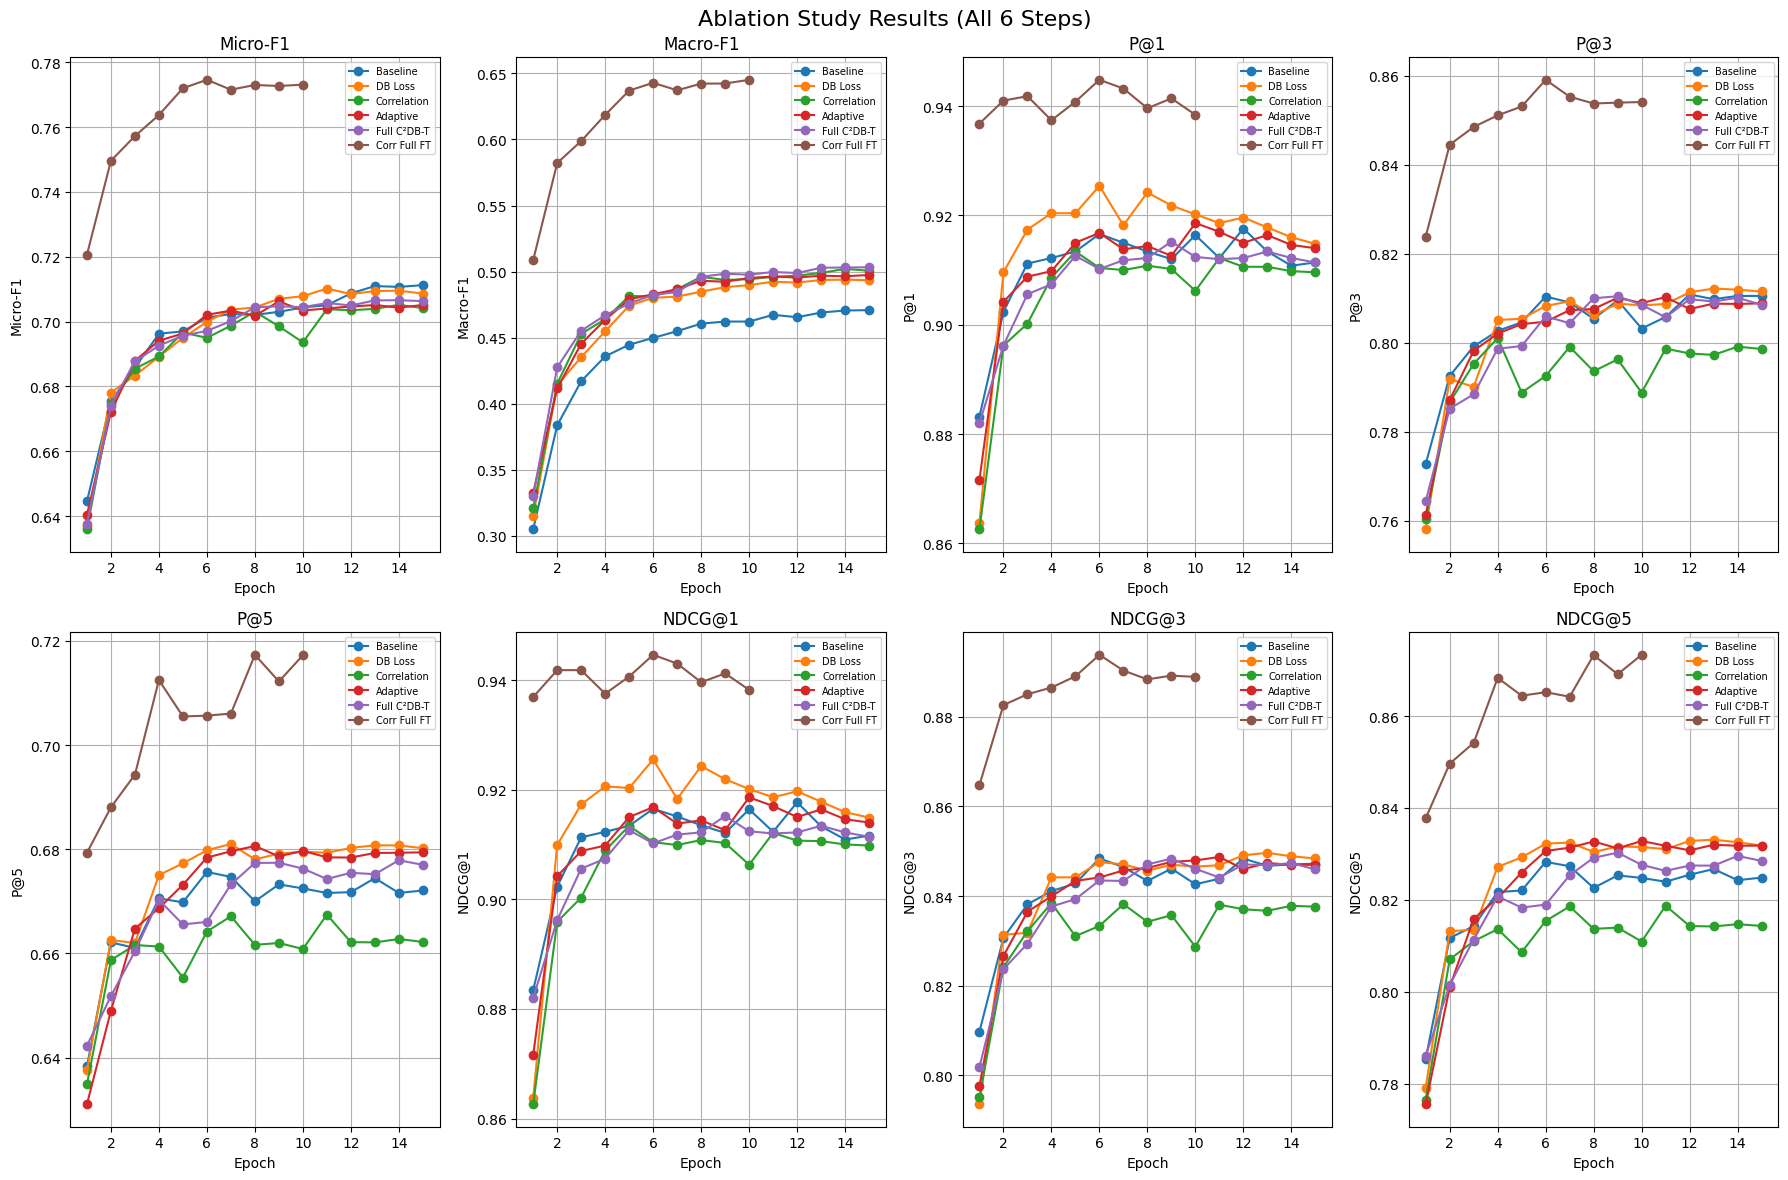

📊 Graphs plotted!


In [13]:
# ── PLOTTING GRAPHS ──────────────────────────────────────────────────────────
models    = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C²DB-T', 'Corr Full FT']
histories = [baseline_hist, db_hist, corr_hist, adapt_hist, full_hist, full_ft_hist]
metrics_to_plot = ['Micro-F1', 'Macro-F1', 'P@1', 'P@3', 'P@5', 'NDCG@1', 'NDCG@3', 'NDCG@5']

plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 4, i+1)
    for model_name, hist in zip(models, histories):
        values = hist[metric]
        plt.plot(range(1, len(values)+1), values, marker='o', label=model_name)
    plt.title(metric); plt.xlabel('Epoch'); plt.ylabel(metric)
    plt.grid(True); plt.legend(fontsize=7)
plt.suptitle('Ablation Study Results (All 6 Steps)', fontsize=16)
plt.tight_layout(); plt.show()
print("📊 Graphs plotted!")

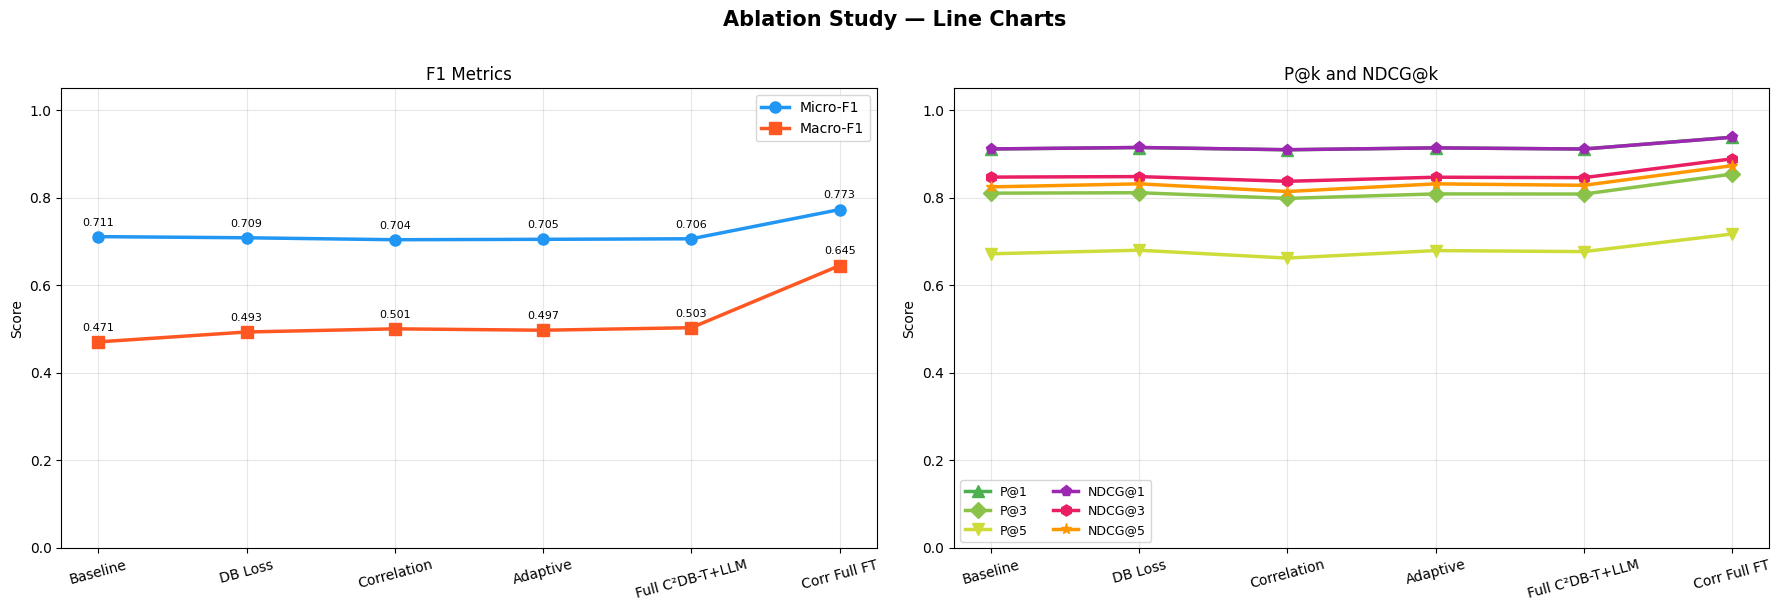

✅ Line chart saved.


In [15]:
COLORS  = {'Micro-F1':'#2196F3','Macro-F1':'#FF5722','P@1':'#4CAF50','P@3':'#8BC34A',
           'P@5':'#CDDC39','NDCG@1':'#9C27B0','NDCG@3':'#E91E63','NDCG@5':'#FF9800'}
MARKERS = {'Micro-F1':'o','Macro-F1':'s','P@1':'^','P@3':'D','P@5':'v',
           'NDCG@1':'p','NDCG@3':'h','NDCG@5':'*'}
x = list(range(len(STEPS)))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Ablation Study — Line Charts', fontsize=15, fontweight='bold', y=1.01)
for k in ['Micro-F1', 'Macro-F1']:
    axes[0].plot(x, final_scores[k], marker=MARKERS[k], color=COLORS[k], linewidth=2.5, markersize=8, label=k)
    for xi, yi in zip(x, final_scores[k]):
        axes[0].annotate(f'{yi:.3f}', xy=(xi, yi), xytext=(0,8), textcoords='offset points', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(STEPS, rotation=15, fontsize=10)
axes[0].set_ylabel('Score'); axes[0].set_title('F1 Metrics'); axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1.05)
for k in ['P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']:
    axes[1].plot(x, final_scores[k], marker=MARKERS[k], color=COLORS[k], linewidth=2.5, markersize=8, label=k)
axes[1].set_xticks(x); axes[1].set_xticklabels(STEPS, rotation=15, fontsize=10)
axes[1].set_ylabel('Score'); axes[1].set_title('P@k and NDCG@k'); axes[1].legend(fontsize=9, ncol=2); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/ablation_line_charts.png', dpi=150, bbox_inches='tight'); plt.show()
print("✅ Line chart saved.")

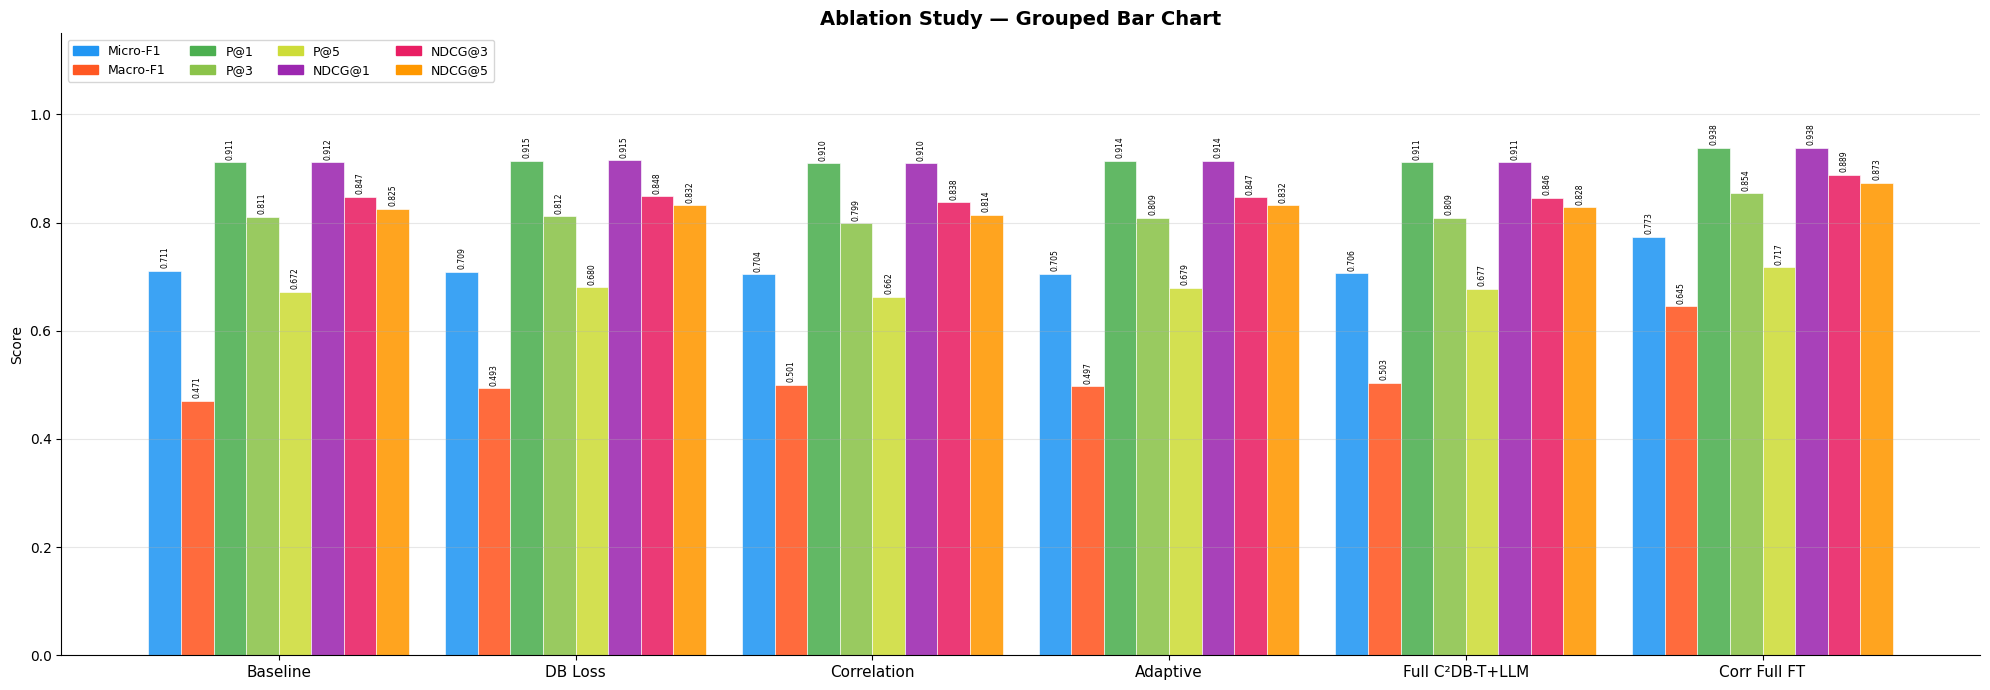

✅ Bar chart saved.


In [17]:
# ── FIGURE 2: BAR CHART ──────────────────────────────────────────────────────
BAR_COLORS = ['#2196F3','#FF5722','#4CAF50','#8BC34A','#CDDC39','#9C27B0','#E91E63','#FF9800']
n_steps = len(STEPS); n_metrics = len(METRIC_KEYS)
bar_width = 0.09; group_gap = 0.10
group_width = n_metrics * bar_width + group_gap
group_centers = np.arange(n_steps) * group_width
fig, ax = plt.subplots(figsize=(20, 7))
for mi, (metric, color) in enumerate(zip(METRIC_KEYS, BAR_COLORS)):
    offsets = group_centers + (mi - n_metrics / 2 + 0.5) * bar_width
    bars = ax.bar(offsets, final_scores[metric], width=bar_width, color=color, label=metric, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h+0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=5.5, rotation=90)
ax.set_xticks(group_centers); ax.set_xticklabels(STEPS, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('Ablation Study — Grouped Bar Chart', fontsize=14, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=c, label=k) for k, c in zip(METRIC_KEYS, BAR_COLORS)], fontsize=9, ncol=4, loc='upper left')
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/ablation_bar_chart.png', dpi=150, bbox_inches='tight'); plt.show()
print("✅ Bar chart saved.")

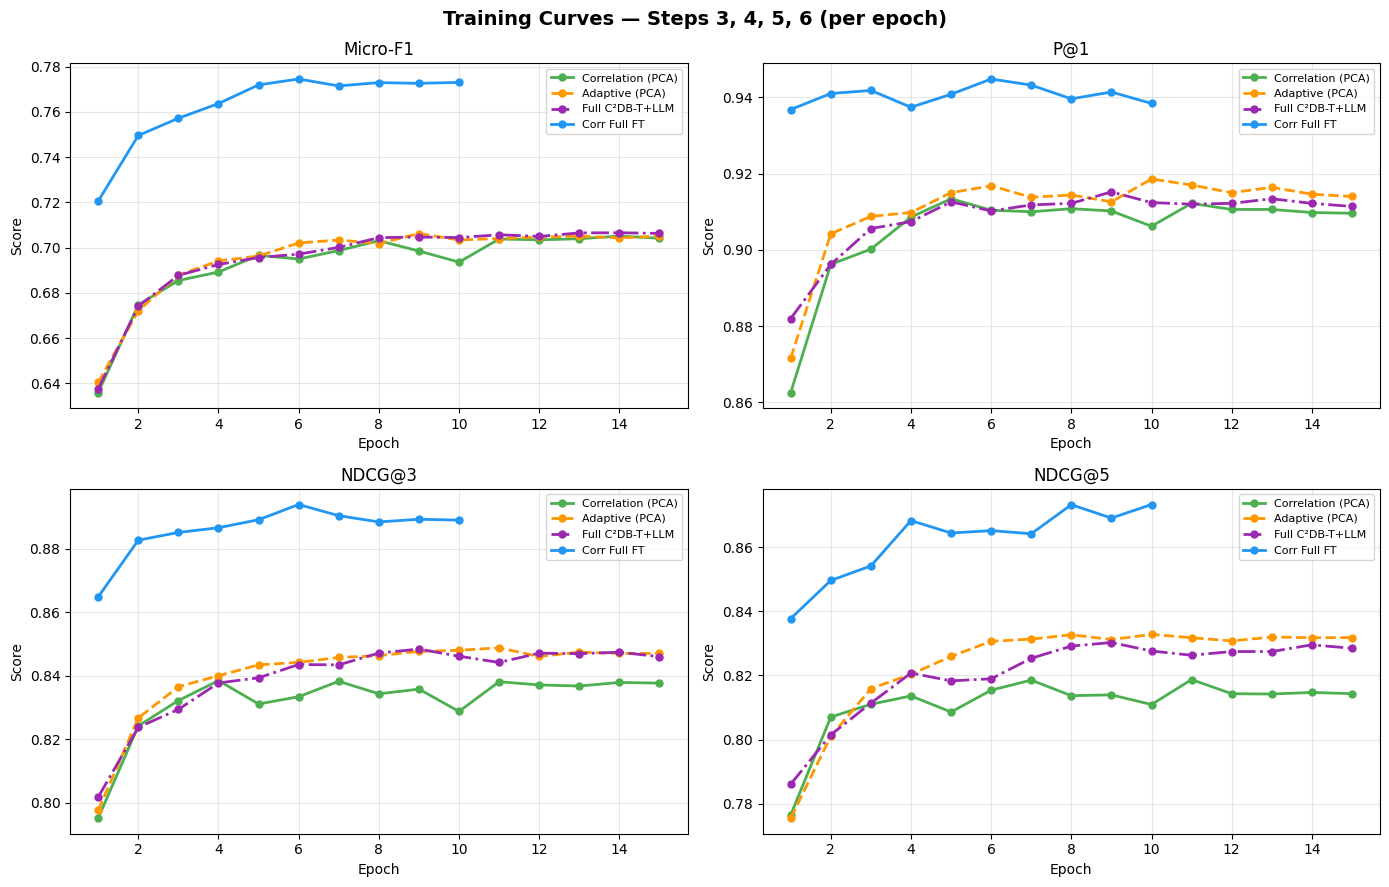

✅ Training curves saved.


In [18]:
# ── FIGURE 3: TRAINING CURVES ────────────────────────────────────────────────
TRAIN_HISTS  = {'Correlation (PCA)': corr_hist, 'Adaptive (PCA)': adapt_hist,
                'Full C²DB-T+LLM': full_hist, 'Corr Full FT': full_ft_hist}
TRAIN_COLORS = {'Correlation (PCA)': '#4CAF50', 'Adaptive (PCA)': '#FF9800',
                'Full C²DB-T+LLM': '#9C27B0', 'Corr Full FT': '#2196F3'}
TRAIN_LINES  = {'Correlation (PCA)': '-', 'Adaptive (PCA)': '--',
                'Full C²DB-T+LLM': '-.', 'Corr Full FT': '-'}
PLOT_METRICS = ['Micro-F1', 'P@1', 'NDCG@3', 'NDCG@5']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training Curves — Steps 3, 4, 5, 6 (per epoch)', fontsize=14, fontweight='bold')
for ax, metric in zip(axes.flat, PLOT_METRICS):
    for name, hist in TRAIN_HISTS.items():
        epochs = range(1, len(hist[metric])+1)
        ax.plot(epochs, hist[metric], marker='o', color=TRAIN_COLORS[name],
                linestyle=TRAIN_LINES[name], linewidth=2, markersize=5, label=name)
    ax.set_title(metric); ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print("✅ Training curves saved.")

In [19]:
# ── IMPROVEMENT SUMMARY ──────────────────────────────────────────────────────
baseline_mf1  = tuned_results['Baseline']['Micro-F1']
db_loss_mf1   = tuned_results['DB Loss']['Micro-F1']
corr_mf1      = tuned_results['Correlation']['Micro-F1']
full_ft_mf1   = tuned_results['Corr Full FT']['Micro-F1']

print(f"Baseline Micro-F1         : {baseline_mf1:.4f}")
print(f"DB Loss Micro-F1          : {db_loss_mf1:.4f}  ({((db_loss_mf1-baseline_mf1)/baseline_mf1)*100:+.2f}% vs baseline)")
print(f"Correlation (PCA) Micro-F1: {corr_mf1:.4f}  ({((corr_mf1-baseline_mf1)/baseline_mf1)*100:+.2f}% vs baseline)")
print(f"Corr Full FT Micro-F1     : {full_ft_mf1:.4f}  ({((full_ft_mf1-baseline_mf1)/baseline_mf1)*100:+.2f}% vs baseline)")
print(f"\nFull FT improvement over PCA Correlation: {((full_ft_mf1-corr_mf1)/corr_mf1)*100:+.2f}%")

Baseline Micro-F1         : 0.7402
DB Loss Micro-F1          : 0.7362  (-0.54% vs baseline)
Correlation (PCA) Micro-F1: 0.7353  (-0.66% vs baseline)
Corr Full FT Micro-F1     : 0.7826  (+5.72% vs baseline)

Full FT improvement over PCA Correlation: +6.43%


In [20]:
# ══════════════════════════════════════════════════════════════════════════
# DATASET SWAP GUIDE — how to run this notebook on any new dataset
# ══════════════════════════════════════════════════════════════════════════
# This entire methodology is dataset-agnostic. To switch datasets:
#
# STEP 1 — Cell 1: change NUM_LABELS
#   NUM_LABELS = 103   # RCV1-V2
#   NUM_LABELS = 54    # AAPD
#   NUM_LABELS = 90    # Reuters-21578
#   NUM_LABELS = 208   # BookMarks
#
# STEP 2 — Cell 3: change dataset loading
#   datasets_raw = load_dataset('rcv1')                    # RCV1-V2
#   datasets_raw = load_dataset('aapd')                    # AAPD
#   datasets_raw = load_dataset('yahoo_answers_topics')    # Yahoo
#   # OR load from local CSV/JSON:
#   # import pandas as pd
#   # df = pd.read_csv('your_data.csv')
#
# STEP 3 — Cell 2: adj_matrix builds AUTOMATICALLY from co-occurrence
#   No manual work needed — build_adj_matrix() handles any label count.
#
# STEP 4 — For multilingual datasets, change encoder in Cell 9 Step 6:
#   full_ft_model = CorrelationModelFull(NUM_LABELS, adj.cpu(),
#                       encoder_name='xlm-roberta-base')   # multilingual
#
# EVERYTHING ELSE — zero change:
#   ✅ PCA pipeline (Cell 3)
#   ✅ DistributionBalancedLoss (Cell 4) — weights compute from new label freq
#   ✅ LabelCorrelationModule (Cell 4)   — uses new adj_matrix automatically
#   ✅ AdaptiveThreshold (Cell 4)        — trains on new NUM_LABELS
#   ✅ All 6 model architectures (Cell 5 + Cell 9 Step 6)
#   ✅ train_model / train_model_full (Cell 8)
#   ✅ Threshold tuning (Cell 10)
#   ✅ All plots and tables (Cells 11-16)
# ══════════════════════════════════════════════════════════════════════════

print("📋 Dataset Swap Checklist:")
print(f"  ✅ NUM_LABELS     = {NUM_LABELS}")
print(f"  ✅ adj_matrix     = {adj_matrix.shape}")
print(f"  ✅ REDUCED_DIM    = {REDUCED_DIM}")
print(f"  ✅ train samples  = {len(orig_train_ds)}")
print(f"  ✅ val samples    = {len(val_ds)}")
print(f"  ✅ aug samples    = {len(aug_ds)}")
print()
print("To use on a new dataset: change NUM_LABELS + dataset loader. Done.")

📋 Dataset Swap Checklist:
  ✅ NUM_LABELS     = 100
  ✅ adj_matrix     = torch.Size([100, 100])
  ✅ REDUCED_DIM    = 512
  ✅ train samples  = 55000
  ✅ val samples    = 5000
  ✅ aug samples    = 7866

To use on a new dataset: change NUM_LABELS + dataset loader. Done.
